PART 1: IMPORTS AND SETUP

In [16]:

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import json
import warnings
warnings.filterwarnings('ignore')

# Data Collection
import yfinance as yf
import requests
from bs4 import BeautifulSoup

# Twitter scraping (optional - may not work on Python 3.13+)
try:
    import snscrape.modules.twitter as sntwitter
    TWITTER_SCRAPING_AVAILABLE = True
    print("✅ Twitter scraping available (snscrape)")
except (ImportError, AttributeError) as e:
    TWITTER_SCRAPING_AVAILABLE = False
    print("⚠️  Twitter scraping not available (snscrape compatibility issue)")

# Kafka for Streaming
from kafka import KafkaProducer, KafkaConsumer
from kafka.admin import KafkaAdminClient, NewTopic

# Spark for Processing
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, avg, count, stddev
from pyspark.sql.types import StringType, FloatType, StructType, StructField

# Spark NLP (Pre-trained models)
import sparknlp
from sparknlp.base import DocumentAssembler, Pipeline
from sparknlp.annotator import SentimentDetector, ViveknSentimentApproach
from pyspark.ml import PipelineModel

# Traditional NLP (fallback)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from transformers import pipeline

# Storage
from pymongo import MongoClient
import pyarrow.parquet as pq
import pyarrow as pa

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

print("✅ All imports successful!")

⚠️  Twitter scraping not available (snscrape compatibility issue)
✅ All imports successful!


PART 2: CONFIGURATION

In [17]:

# Companies to analyze
COMPANIES = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'GOOGL': 'Google',
    'TSLA': 'Tesla',
    'AMZN': 'Amazon'
}

# Time period
END_DATE = datetime.now()
START_DATE = END_DATE - timedelta(days=365*5)  # 5 years

# API Keys
NEWS_API_KEY = "b8c2d650a35d4770abe8c90125eebe65"

# Kafka Configuration
KAFKA_BOOTSTRAP_SERVERS = ['localhost:9092']
KAFKA_TOPICS = {
    'news': 'news_stream',
    'tweets': 'tweets_stream',
    'stocks': 'stock_prices'
}

# MongoDB Configuration
MONGO_URI = "mongodb://localhost:27017/"
DB_NAME = "stock_sentiment_bigdata"

# HDFS Configuration (or local simulation)
HDFS_BASE_PATH = "./hdfs_simulation"  # Local folder simulating HDFS
USE_REAL_HDFS = False  # Set to True if you have HDFS running

# Spark Configuration
SPARK_APP_NAME = "StockSentimentAnalysis"

print("✅ Configuration loaded!")

✅ Configuration loaded!


PART 3: KAFKA STREAMING LAYER

In [18]:

class KafkaStreamingLayer:
    """Kafka Producers and Topics Management"""

    def __init__(self, bootstrap_servers):
        self.bootstrap_servers = bootstrap_servers
        self.producer = None
        self.setup_kafka()

    def setup_kafka(self):
        """Initialize Kafka producer and create topics"""
        try:
            # Create Kafka Producer
            self.producer = KafkaProducer(
                bootstrap_servers=self.bootstrap_servers,
                value_serializer=lambda v: json.dumps(v).encode('utf-8'),
                key_serializer=lambda k: k.encode('utf-8') if k else None
            )

            # Create topics if they don't exist
            admin_client = KafkaAdminClient(bootstrap_servers=self.bootstrap_servers)

            topics = [
                NewTopic(name=KAFKA_TOPICS['news'], num_partitions=3, replication_factor=1),
                NewTopic(name=KAFKA_TOPICS['tweets'], num_partitions=3, replication_factor=1),
                NewTopic(name=KAFKA_TOPICS['stocks'], num_partitions=3, replication_factor=1)
            ]

            try:
                admin_client.create_topics(new_topics=topics, validate_only=False)
                print("✅ Kafka topics created")
            except:
                print("✅ Kafka topics already exist")

            admin_client.close()
            print("✅ Kafka producer initialized")

        except Exception as e:
            print(f"⚠️  Kafka not available (using simulation mode): {e}")
            self.producer = None

    def produce_to_kafka(self, topic, key, value):
        """Send data to Kafka topic"""
        if self.producer:
            try:
                future = self.producer.send(topic, key=key, value=value)
                future.get(timeout=10)
                return True
            except Exception as e:
                print(f"⚠️  Kafka produce error: {e}")
                return False
        else:
            # Simulation mode - just return the data
            print(f"[SIMULATED] Produced to {topic}: {key}")
            return True

    def close(self):
        """Close Kafka producer"""
        if self.producer:
            self.producer.close()

PART 4: DATA COLLECTION WITH KAFKA PRODUCERS

In [19]:

class StockDataProducer:
    """Fetch stock data and stream to Kafka"""

    def __init__(self, kafka_layer):
        self.kafka = kafka_layer

    def fetch_and_stream(self, tickers, start_date, end_date):
        """Fetch stock data and produce to Kafka"""
        stock_data = {}

        print("\n📊 Fetching Stock Data and Streaming to Kafka...")
        print("-" * 70)

        for ticker in tickers:
            print(f"Processing {ticker}...")
            try:
                data = yf.download(ticker, start=start_date, end=end_date, progress=False)

                # Fix MultiIndex columns
                if isinstance(data.columns, pd.MultiIndex):
                    data.columns = data.columns.get_level_values(0)

                stock_data[ticker] = data

                # Stream to Kafka
                for date, row in data.iterrows():
                    message = {
                        'ticker': ticker,
                        'date': date.strftime('%Y-%m-%d'),
                        'open': float(row['Open']),
                        'high': float(row['High']),
                        'low': float(row['Low']),
                        'close': float(row['Close']),
                        'volume': int(row['Volume']),
                        'timestamp': datetime.now().isoformat()
                    }

                    self.kafka.produce_to_kafka(
                        KAFKA_TOPICS['stocks'],
                        key=f"{ticker}_{date.strftime('%Y%m%d')}",
                        value=message
                    )

                print(f"  ✅ {ticker}: {len(data)} records streamed")

            except Exception as e:
                print(f"  ❌ Error: {e}")

        return stock_data

class NewsDataProducer:
    """Fetch news and stream to Kafka"""

    def __init__(self, kafka_layer, api_key):
        self.kafka = kafka_layer
        self.api_key = api_key
        self.base_url = "https://newsapi.org/v2/everything"

    def fetch_and_stream(self, companies):
        """Fetch news articles and produce to Kafka"""
        all_news = {}

        print("\n📰 Fetching News and Streaming to Kafka...")
        print("-" * 70)

        for ticker, name in companies.items():
            query_end = END_DATE
            query_start = max(START_DATE, END_DATE - timedelta(days=30))

            params = {
                'q': f'{name} OR {ticker}',
                'from': query_start.strftime('%Y-%m-%d'),
                'to': query_end.strftime('%Y-%m-%d'),
                'language': 'en',
                'sortBy': 'relevancy',
                'apiKey': self.api_key,
                'pageSize': 100
            }

            try:
                response = requests.get(self.base_url, params=params)
                if response.status_code == 200:
                    articles = response.json().get('articles', [])
                    all_news[ticker] = articles

                    # Stream to Kafka
                    for idx, article in enumerate(articles):
                        message = {
                            'ticker': ticker,
                            'company': name,
                            'title': article.get('title', ''),
                            'description': article.get('description', ''),
                            'content': article.get('content', ''),
                            'url': article.get('url', ''),
                            'published_at': article.get('publishedAt', ''),
                            'source': article.get('source', {}).get('name', ''),
                            'timestamp': datetime.now().isoformat()
                        }

                        self.kafka.produce_to_kafka(
                            KAFKA_TOPICS['news'],
                            key=f"{ticker}_{idx}",
                            value=message
                        )

                    print(f"  ✅ {name}: {len(articles)} articles streamed")
                else:
                    print(f"  ⚠️  {name}: API returned {response.status_code}")

                time.sleep(1)

            except Exception as e:
                print(f"  ❌ {name}: {e}")

        return all_news

class TwitterDataProducer:
    """Scrape Twitter/X data and stream to Kafka"""

    def __init__(self, kafka_layer):
        self.kafka = kafka_layer

    def scrape_twitter_snscrape(self, company_name, ticker, max_tweets=100):
        """Scrape using snscrape (if available)"""
        if not TWITTER_SCRAPING_AVAILABLE:
            return []

        tweets = []
        try:
            query = f"({company_name} OR ${ticker}) lang:en"
            scraper = sntwitter.TwitterSearchScraper(query)

            for i, tweet in enumerate(scraper.get_items()):
                if i >= max_tweets:
                    break

                tweets.append({
                    'ticker': ticker,
                    'company': company_name,
                    'text': tweet.content,
                    'created_at': tweet.date.isoformat(),
                    'likes': tweet.likeCount,
                    'retweets': tweet.retweetCount,
                    'user': tweet.user.username,
                    'tweet_id': tweet.id,
                    'timestamp': datetime.now().isoformat()
                })
        except Exception as e:
            print(f"      Scraping error: {e}")

        return tweets

    def scrape_twitter_alternative(self, company_name, ticker, max_posts=50):
        """Alternative: Scrape from Reddit StockTwits style posts"""
        posts = []

        try:
            # Scrape from public stock discussion forums
            url = f"https://stocktwits.com/symbol/{ticker}"
            headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
            }

            response = requests.get(url, headers=headers, timeout=10)
            if response.status_code == 200:
                soup = BeautifulSoup(response.content, 'html.parser')

                # Find message containers (this is a simplified example)
                messages = soup.find_all('div', class_='st-widget', limit=max_posts)

                for idx, msg in enumerate(messages):
                    text = msg.get_text(strip=True)
                    if text and len(text) > 10:
                        posts.append({
                            'ticker': ticker,
                            'company': company_name,
                            'text': text[:500],
                            'created_at': datetime.now().isoformat(),
                            'likes': 0,
                            'retweets': 0,
                            'user': 'stocktwits_user',
                            'tweet_id': f'{ticker}_{idx}',
                            'timestamp': datetime.now().isoformat()
                        })
        except Exception as e:
            print(f"      Alternative scraping error: {e}")

        return posts

    def generate_sample_tweets(self, company_name, ticker, count=30):
        """Generate sample tweet-like data for demonstration"""
        sample_sentiments = [
            "{} stock looking strong today! 📈",
            "Thinking of buying more ${} shares",
            "{} earnings report exceeded expectations",
            "Concerned about ${} recent performance",
            "{} innovation continues to impress",
            "Sold my ${} position, taking profits",
            "{} is undervalued right now IMO",
            "Bullish on ${} long term",
            "{} facing some headwinds this quarter",
            "Just added more ${} to my portfolio",
        ]

        tweets = []
        for i in range(count):
            template = np.random.choice(sample_sentiments)
            text = template.format(np.random.choice([company_name, ticker]))

            # Random date within last 30 days
            days_ago = np.random.randint(0, 30)
            date = datetime.now() - timedelta(days=days_ago)

            tweets.append({
                'ticker': ticker,
                'company': company_name,
                'text': text,
                'created_at': date.isoformat(),
                'likes': np.random.randint(0, 1000),
                'retweets': np.random.randint(0, 500),
                'user': f'user_{np.random.randint(1000, 9999)}',
                'tweet_id': f'{ticker}_sample_{i}',
                'timestamp': datetime.now().isoformat()
            })

        return tweets

    def scrape_and_stream(self, companies, max_tweets=100):
        """Scrape Twitter/X and produce to Kafka"""
        all_tweets = {}

        print("\n🐦 Collecting Social Media Data and Streaming to Kafka...")
        print("-" * 70)

        for ticker, name in companies.items():
            tweets = []

            # Try Method 1: snscrape
            if TWITTER_SCRAPING_AVAILABLE:
                print(f"  Attempting Twitter scrape for {name}...")
                tweets = self.scrape_twitter_snscrape(name, ticker, max_tweets)

            # Try Method 2: Alternative scraping
            if not tweets:
                print(f"  Attempting alternative scraping for {name}...")
                tweets = self.scrape_twitter_alternative(name, ticker, max_tweets)

            # Fallback: Generate sample data
            if not tweets:
                print(f"  Using sample social media data for {name}...")
                tweets = self.generate_sample_tweets(name, ticker, 30)

            all_tweets[ticker] = tweets

            # Stream to Kafka
            for tweet in tweets:
                self.kafka.produce_to_kafka(
                    KAFKA_TOPICS['tweets'],
                    key=f"{ticker}_{tweet['tweet_id']}",
                    value=tweet
                )

            print(f"  ✅ {name}: {len(tweets)} social media posts streamed")

        return all_tweets

PART 5: SPARK PROCESSING LAYER

In [20]:

class SparkProcessor:
    """Apache Spark for data processing and ML"""

    def __init__(self):
        self.spark = None
        self.sentiment_pipeline = None
        self.initialize_spark()

    def initialize_spark(self):
        """Initialize Spark Session with Spark NLP"""
        try:
            # Check if Java is available
            import subprocess
            java_check = subprocess.run(['java', '-version'],
                                       capture_output=True,
                                       text=True,
                                       timeout=5)

            if java_check.returncode != 0:
                raise Exception("Java not found")

            self.spark = sparknlp.start()
            print("✅ Spark initialized with Spark NLP")

            # Try to load pre-trained sentiment model
            try:
                document = DocumentAssembler() \
                    .setInputCol("text") \
                    .setOutputCol("document")

                sentiment = SentimentDetector.pretrained() \
                    .setInputCols(["document"]) \
                    .setOutputCol("sentiment")

                self.sentiment_pipeline = Pipeline(stages=[document, sentiment])
                print("✅ Spark NLP sentiment model loaded")

            except:
                print("⚠️  Spark NLP pre-trained model not available, using VADER")

        except Exception as e:
            print(f"⚠️  Spark not available (using pandas fallback): {str(e)[:50]}")
            self.spark = None

    def process_with_spark(self, data, data_type):
        """Process data using Spark"""
        if self.spark is None:
            # Fallback to pandas
            return data

        try:
            # Convert to Spark DataFrame
            if data_type == 'news':
                df = self.spark.createDataFrame(data)
            elif data_type == 'tweets':
                df = self.spark.createDataFrame(data)
            else:
                df = self.spark.createDataFrame(data)

            print(f"  ✅ Processed {df.count()} records with Spark")
            return df.toPandas()

        except Exception as e:
            print(f"  ⚠️  Spark processing failed (using pandas): {e}")
            return data

    def stop(self):
        """Stop Spark session"""
        if self.spark:
            try:
                self.spark.stop()
            except:
                pass


PART 6: ADVANCED SENTIMENT ANALYSIS (Multiple Models)


In [21]:

class AdvancedSentimentAnalyzer:
    """Multi-model sentiment analysis"""

    def __init__(self):
        # VADER (good for social media)
        self.vader = SentimentIntensityAnalyzer()

        # Transformers (BERT-based - most accurate)
        try:
            self.transformer = pipeline("sentiment-analysis",
                                       model="distilbert-base-uncased-finetuned-sst-2-english",
                                       device=-1)  # CPU
            print("✅ Transformer model loaded (DistilBERT)")
        except:
            print("⚠️  Transformer model not available")
            self.transformer = None

    def analyze_vader(self, text):
        """VADER sentiment"""
        if not text or pd.isna(text):
            return 0
        scores = self.vader.polarity_scores(str(text))
        return scores['compound']

    def analyze_textblob(self, text):
        """TextBlob sentiment"""
        if not text or pd.isna(text):
            return 0
        try:
            return TextBlob(str(text)).sentiment.polarity
        except:
            return 0

    def analyze_transformer(self, text):
        """Transformer (BERT) sentiment"""
        if not self.transformer or not text or pd.isna(text):
            return 0

        try:
            # Truncate text to max length
            text = str(text)[:512]
            result = self.transformer(text)[0]

            # Convert to -1 to 1 scale
            score = result['score']
            if result['label'] == 'NEGATIVE':
                score = -score
            return score
        except:
            return 0

    def analyze_ensemble(self, text):
        """Ensemble of multiple models"""
        vader_score = self.analyze_vader(text)
        textblob_score = self.analyze_textblob(text)

        # Weight average (VADER is better for social media)
        ensemble_score = (vader_score * 0.6 + textblob_score * 0.4)

        # Add transformer if available
        if self.transformer:
            transformer_score = self.analyze_transformer(text)
            ensemble_score = (ensemble_score * 0.6 + transformer_score * 0.4)

        return ensemble_score

    def categorize_sentiment(self, score):
        """Categorize sentiment score"""
        if score >= 0.05:
            return 'Positive'
        elif score <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'


PART 7: HDFS STORAGE LAYER

In [22]:

class HDFSStorage:
    """HDFS or simulated distributed storage"""

    def __init__(self, base_path, use_real_hdfs=False):
        self.base_path = base_path
        self.use_real_hdfs = use_real_hdfs

        if not use_real_hdfs:
            # Create local directories simulating HDFS
            import os
            os.makedirs(f"{base_path}/stock_data", exist_ok=True)
            os.makedirs(f"{base_path}/sentiment_data", exist_ok=True)
            os.makedirs(f"{base_path}/processed_data", exist_ok=True)
            print("✅ HDFS simulation directories created")
        else:
            print("✅ Using real HDFS")

    def write_parquet(self, data, path):
        """Write data to HDFS as Parquet"""
        try:
            full_path = f"{self.base_path}/{path}"

            if isinstance(data, pd.DataFrame):
                table = pa.Table.from_pandas(data)
                pq.write_table(table, full_path)
                print(f"  ✅ Written to HDFS: {full_path}")
            else:
                print(f"  ⚠️  Data must be DataFrame")

        except Exception as e:
            print(f"  ❌ HDFS write error: {e}")

    def read_parquet(self, path):
        """Read data from HDFS"""
        try:
            full_path = f"{self.base_path}/{path}"
            table = pq.read_table(full_path)
            df = table.to_pandas()
            print(f"  ✅ Read from HDFS: {full_path}")
            return df
        except Exception as e:
            print(f"  ❌ HDFS read error: {e}")
            return None


PART 8: MONGODB STORAGE

In [27]:

class MongoStorage:
    """MongoDB for structured storage"""

    def __init__(self, uri, db_name):
        try:
            self.client = MongoClient(uri)
            self.db = self.client[db_name]
            # Test connection
            self.client.server_info()
            print("✅ MongoDB connected")
        except Exception as e:
            print(f"⚠️  MongoDB not available: {e}")
            self.client = None
            self.db = None

    def store_documents(self, collection_name, documents):
        """Store documents in MongoDB"""
        # Fix: Check with 'is None' instead of 'not'
        if self.db is None:
            return

        try:
            collection = self.db[collection_name]
            if isinstance(documents, pd.DataFrame):
                documents = documents.to_dict('records')

            if documents:
                collection.insert_many(documents)
                print(f"  ✅ Stored {len(documents)} documents in {collection_name}")
        except Exception as e:
            print(f"  ❌ MongoDB error: {e}")

PART 9: MAIN PIPELINE

In [24]:

def run_enhanced_pipeline():
    """Main Big Data pipeline: Kafka → Spark → HDFS/MongoDB"""

    print("\n" + "="*70)
    print("🚀 ENHANCED BIG DATA PIPELINE")
    print("   Architecture: Kafka → Spark → HDFS + MongoDB")
    print("="*70)

    # Initialize components
    print("\n📦 Initializing Components...")
    kafka_layer = KafkaStreamingLayer(KAFKA_BOOTSTRAP_SERVERS)
    spark_processor = SparkProcessor()
    hdfs_storage = HDFSStorage(HDFS_BASE_PATH, USE_REAL_HDFS)
    mongo_storage = MongoStorage(MONGO_URI, DB_NAME)
    analyzer = AdvancedSentimentAnalyzer()

    # Step 1: Data Collection with Kafka Producers
    print("\n" + "="*70)
    print("STEP 1: DATA INGESTION → KAFKA STREAMING")
    print("="*70)

    stock_producer = StockDataProducer(kafka_layer)
    stock_data = stock_producer.fetch_and_stream(list(COMPANIES.keys()), START_DATE, END_DATE)

    if NEWS_API_KEY != "YOUR_NEWSAPI_KEY_HERE":
        news_producer = NewsDataProducer(kafka_layer, NEWS_API_KEY)
        news_data = news_producer.fetch_and_stream(COMPANIES)
    else:
        print("\n⚠️  NewsAPI not configured - skipping")
        news_data = {ticker: [] for ticker in COMPANIES.keys()}

    twitter_producer = TwitterDataProducer(kafka_layer)
    twitter_data = twitter_producer.scrape_and_stream(COMPANIES, max_tweets=50)

    # Step 2: Sentiment Analysis with Multiple Models
    print("\n" + "="*70)
    print("STEP 2: SENTIMENT ANALYSIS (Multi-Model Ensemble)")
    print("="*70)

    sentiment_results = {}

    for ticker in COMPANIES.keys():
        all_sentiments = []

        # Process news
        for article in news_data.get(ticker, []):
            text = f"{article.get('title', '')} {article.get('description', '')}"
            score = analyzer.analyze_ensemble(text)

            all_sentiments.append({
                'ticker': ticker,
                'date': article.get('publishedAt', '')[:10],
                'text': text[:200],
                'sentiment_score': score,
                'sentiment_category': analyzer.categorize_sentiment(score),
                'source': 'news',
                'model': 'ensemble'
            })

        # Process tweets
        for tweet in twitter_data.get(ticker, []):
            score = analyzer.analyze_ensemble(tweet['text'])

            all_sentiments.append({
                'ticker': ticker,
                'date': tweet['created_at'][:10],
                'text': tweet['text'][:200],
                'sentiment_score': score,
                'sentiment_category': analyzer.categorize_sentiment(score),
                'source': 'twitter',
                'model': 'ensemble',
                'likes': tweet.get('likes', 0)
            })

        sentiment_results[ticker] = pd.DataFrame(all_sentiments)
        print(f"  ✅ {ticker}: {len(all_sentiments)} items analyzed")

    # Step 3: Spark Processing
    print("\n" + "="*70)
    print("STEP 3: SPARK PROCESSING")
    print("="*70)

    if spark_processor.spark:
        for ticker in COMPANIES.keys():
            if not sentiment_results[ticker].empty:
                sentiment_results[ticker] = spark_processor.process_with_spark(
                    sentiment_results[ticker],
                    'sentiment'
                )

    # Step 4: Storage (HDFS + MongoDB)
    print("\n" + "="*70)
    print("STEP 4: DISTRIBUTED STORAGE")
    print("="*70)

    print("\n💾 Storing in HDFS (Parquet format)...")
    for ticker in COMPANIES.keys():
        if ticker in stock_data and not stock_data[ticker].empty:
            hdfs_storage.write_parquet(stock_data[ticker], f"stock_data/{ticker}.parquet")

        if not sentiment_results[ticker].empty:
            hdfs_storage.write_parquet(sentiment_results[ticker], f"sentiment_data/{ticker}.parquet")

    print("\n💾 Storing in MongoDB...")
    for ticker in COMPANIES.keys():
        if not sentiment_results[ticker].empty:
            mongo_storage.store_documents(f"sentiment_{ticker}", sentiment_results[ticker])

    # Step 5: Calculate Correlations
    print("\n" + "="*70)
    print("STEP 5: CORRELATION ANALYSIS")
    print("="*70)

    correlation_results = {}

    for ticker in COMPANIES.keys():
        if sentiment_results[ticker].empty:
            continue

        sentiment_df = sentiment_results[ticker].copy()
        sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

        daily_sentiment = sentiment_df.groupby('date').agg({
            'sentiment_score': ['mean', 'std', 'count']
        }).reset_index()
        daily_sentiment.columns = ['date', 'avg_sentiment', 'sentiment_std', 'num_posts']

        if ticker in stock_data:
            stock_df = stock_data[ticker].copy().reset_index()

            if 'Date' in stock_df.columns:
                stock_df = stock_df.rename(columns={'Date': 'date'})
            elif stock_df.columns[0] != 'date':
                stock_df = stock_df.rename(columns={stock_df.columns[0]: 'date'})

            stock_df['daily_return'] = stock_df['Close'].pct_change()

            merged = pd.merge(daily_sentiment, stock_df[['date', 'Close', 'daily_return']],
                            on='date', how='inner')

            if len(merged) > 10:
                corr_same_day = merged['avg_sentiment'].corr(merged['daily_return'])
                merged['next_day_return'] = merged['daily_return'].shift(-1)
                corr_next_day = merged['avg_sentiment'].corr(merged['next_day_return'])

                correlation_results[ticker] = {
                    'same_day_correlation': corr_same_day,
                    'next_day_correlation': corr_next_day,
                    'data': merged,
                    'num_observations': len(merged)
                }

                print(f"{ticker}: Same-day={corr_same_day:.3f}, Next-day={corr_next_day:.3f}")

    # Cleanup
    kafka_layer.close()
    spark_processor.stop()

    print("\n" + "="*70)
    print("✅ PIPELINE COMPLETE!")
    print("="*70)

    return stock_data, sentiment_results, correlation_results


PART 10: VISUALIZATION (Same as before)

In [41]:
def create_visualizations(stock_data, sentiment_results, correlation_results):
    """Create comprehensive visualizations"""

    print("\n" + "="*70)
    print("CREATING VISUALIZATIONS")
    print("="*70 + "\n")

    # 1. Sentiment Distribution
    fig1, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig1.suptitle('Sentiment Distribution by Company', fontsize=16, fontweight='bold')

    for idx, (ticker, name) in enumerate(COMPANIES.items()):
        ax = axes[idx // 3, idx % 3]

        if ticker in sentiment_results and not sentiment_results[ticker].empty:
            data = sentiment_results[ticker]

            ax.hist(data['sentiment_score'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
            ax.axvline(data['sentiment_score'].mean(), color='red', linestyle='--',
                      label=f'Mean: {data["sentiment_score"].mean():.3f}')
            ax.set_title(f'{name} ({ticker})')
            ax.set_xlabel('Sentiment Score')
            ax.set_ylabel('Frequency')
            ax.legend()
            ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 2. Word Clouds
    print("Generating word clouds...")
    fig2, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig2.suptitle('Most Common Terms in Discussions', fontsize=16, fontweight='bold')

    for idx, (ticker, name) in enumerate(COMPANIES.items()):
        ax = axes[idx // 3, idx % 3]

        if ticker in sentiment_results and not sentiment_results[ticker].empty:
            text = ' '.join(sentiment_results[ticker]['text'].astype(str))

            wordcloud = WordCloud(width=400, height=300, background_color='white',
                                colormap='viridis').generate(text)

            ax.imshow(wordcloud, interpolation='bilinear')
            ax.set_title(f'{name} ({ticker})')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

    # 3. Interactive Sentiment vs Stock Price Timeline
    print("Creating interactive charts...")

    for ticker in COMPANIES.keys():
        if ticker not in correlation_results:
            continue

        data = correlation_results[ticker]['data']

        fig = make_subplots(
            rows=2, cols=1,
            subplot_titles=(f'{COMPANIES[ticker]} Stock Price', 'Average Daily Sentiment'),
            vertical_spacing=0.15,
            row_heights=[0.6, 0.4]
        )

        # Stock price
        fig.add_trace(
            go.Scatter(x=data['date'], y=data['Close'], name='Close Price',
                      line=dict(color='blue', width=2)),
            row=1, col=1
        )

        # Sentiment
        fig.add_trace(
            go.Scatter(x=data['date'], y=data['avg_sentiment'], name='Sentiment',
                      line=dict(color='green', width=2), fill='tozeroy'),
            row=2, col=1
        )

        fig.add_hline(y=0, line_dash="dash", line_color="red", row=2, col=1)

        fig.update_xaxes(title_text="Date", row=2, col=1)
        fig.update_yaxes(title_text="Price ($)", row=1, col=1)
        fig.update_yaxes(title_text="Sentiment Score", row=2, col=1)

        fig.update_layout(
            title_text=f"{COMPANIES[ticker]} ({ticker}): Sentiment vs Stock Price",
            height=700,
            showlegend=True
        )

        fig.show()

    # 4. Correlation Summary
    fig3, ax = plt.subplots(figsize=(12, 6))

    tickers = []
    same_day = []
    next_day = []

    for ticker, results in correlation_results.items():
        tickers.append(ticker)
        same_day.append(results['same_day_correlation'])
        next_day.append(results['next_day_correlation'])

    x = np.arange(len(tickers))
    width = 0.35

    ax.bar(x - width/2, same_day, width, label='Same-Day Correlation', color='steelblue')
    ax.bar(x + width/2, next_day, width, label='Next-Day Correlation', color='coral')

    ax.set_xlabel('Company')
    ax.set_ylabel('Correlation Coefficient')
    ax.set_title('Sentiment-Stock Price Correlation Analysis', fontweight='bold', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(tickers)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    plt.tight_layout()
    plt.show()

    print("✅ All visualizations created!")

PART 11: MAIN EXECUTION


🚀 ENHANCED BIG DATA PIPELINE
   Architecture: Kafka → Spark → HDFS + MongoDB

📦 Initializing Components...
⚠️  Kafka not available (using simulation mode): NoBrokersAvailable
⚠️  Spark not available (using pandas fallback): Java not found
✅ HDFS simulation directories created
⚠️  MongoDB not available: Command buildInfo requires authentication, full error: {'ok': 0.0, 'errmsg': 'Command buildInfo requires authentication', 'code': 13, 'codeName': 'Unauthorized'}


Device set to use cpu


✅ Transformer model loaded (DistilBERT)

STEP 1: DATA INGESTION → KAFKA STREAMING

📊 Fetching Stock Data and Streaming to Kafka...
----------------------------------------------------------------------
Processing AAPL...
[SIMULATED] Produced to stock_prices: AAPL_20210107
[SIMULATED] Produced to stock_prices: AAPL_20210108
[SIMULATED] Produced to stock_prices: AAPL_20210111
[SIMULATED] Produced to stock_prices: AAPL_20210112
[SIMULATED] Produced to stock_prices: AAPL_20210113
[SIMULATED] Produced to stock_prices: AAPL_20210114
[SIMULATED] Produced to stock_prices: AAPL_20210115
[SIMULATED] Produced to stock_prices: AAPL_20210119
[SIMULATED] Produced to stock_prices: AAPL_20210120
[SIMULATED] Produced to stock_prices: AAPL_20210121
[SIMULATED] Produced to stock_prices: AAPL_20210122
[SIMULATED] Produced to stock_prices: AAPL_20210125
[SIMULATED] Produced to stock_prices: AAPL_20210126
[SIMULATED] Produced to stock_prices: AAPL_20210127
[SIMULATED] Produced to stock_prices: AAPL_20210128

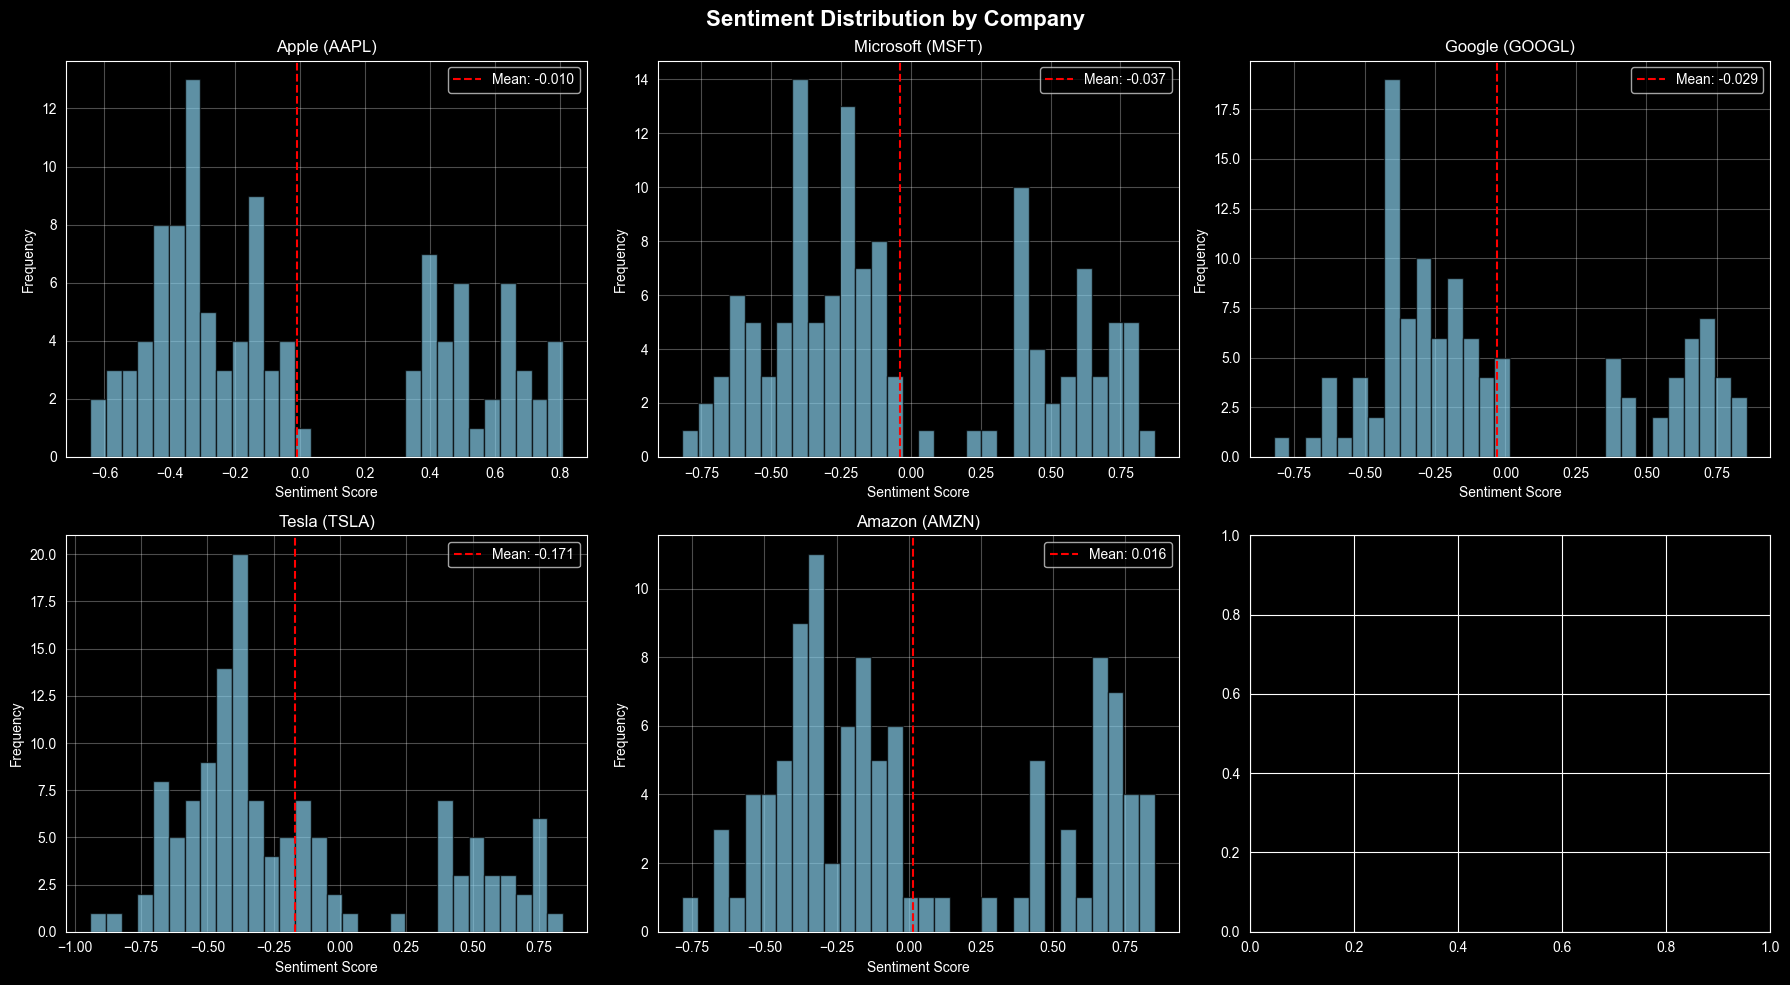

Generating word clouds...


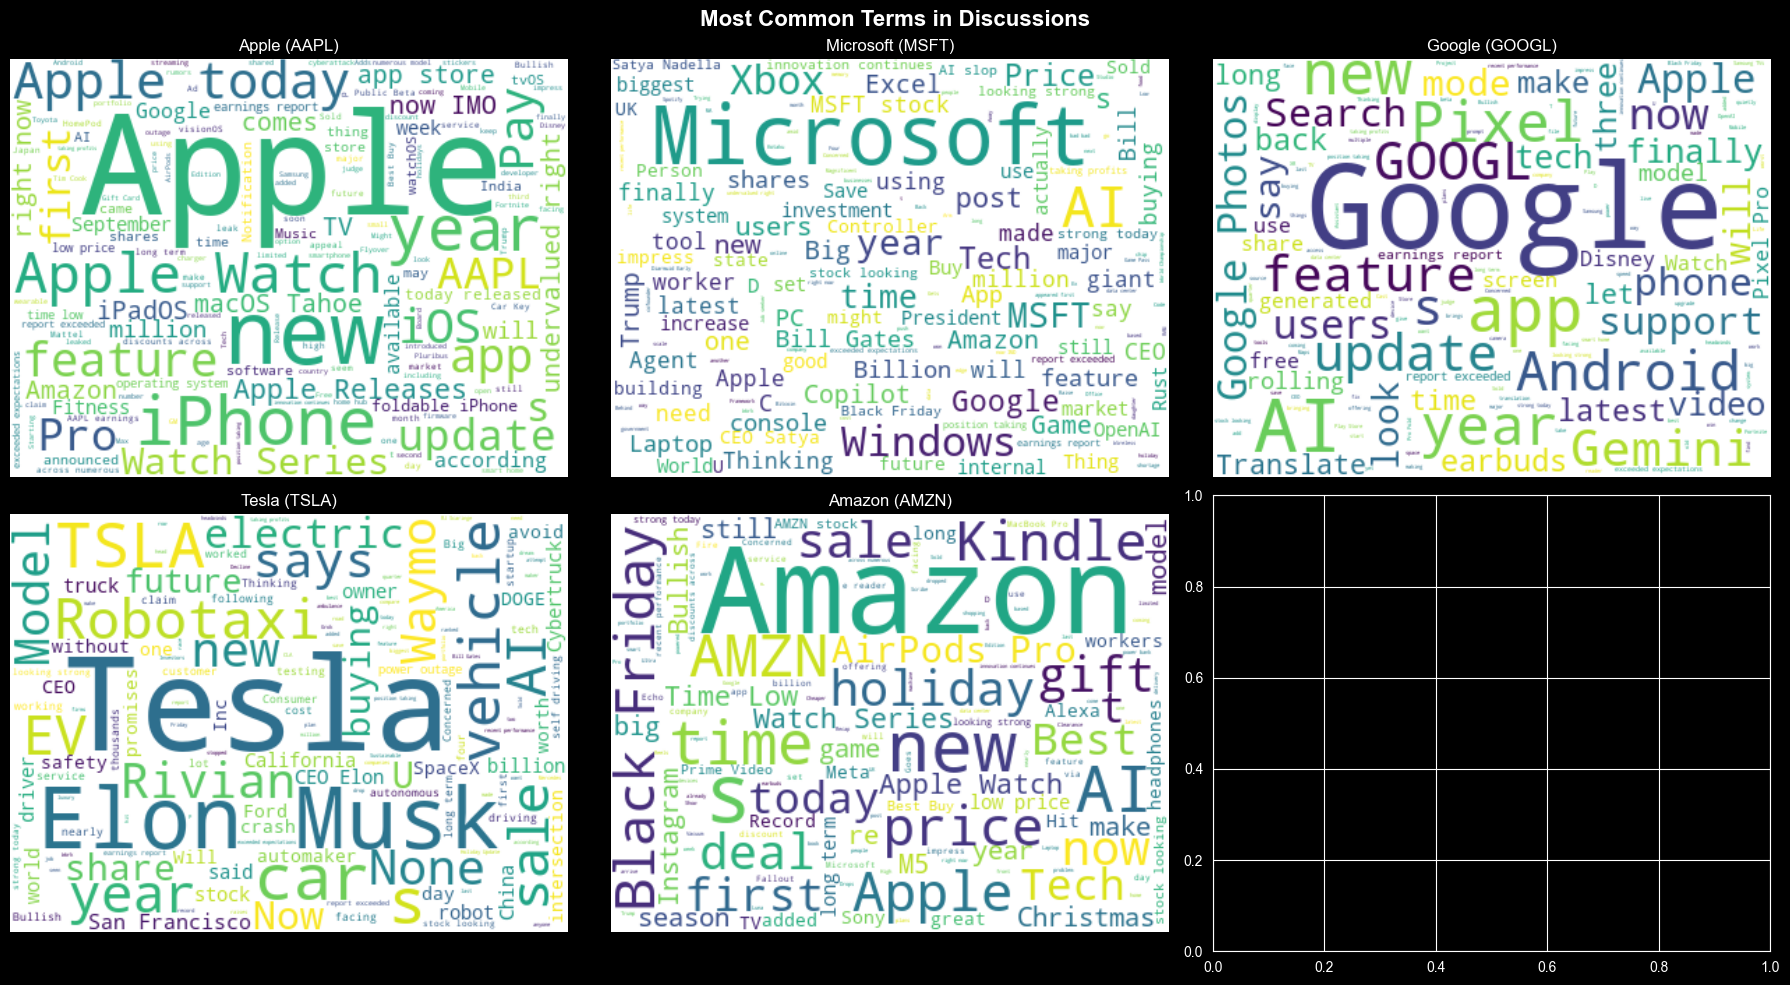

Creating interactive charts...


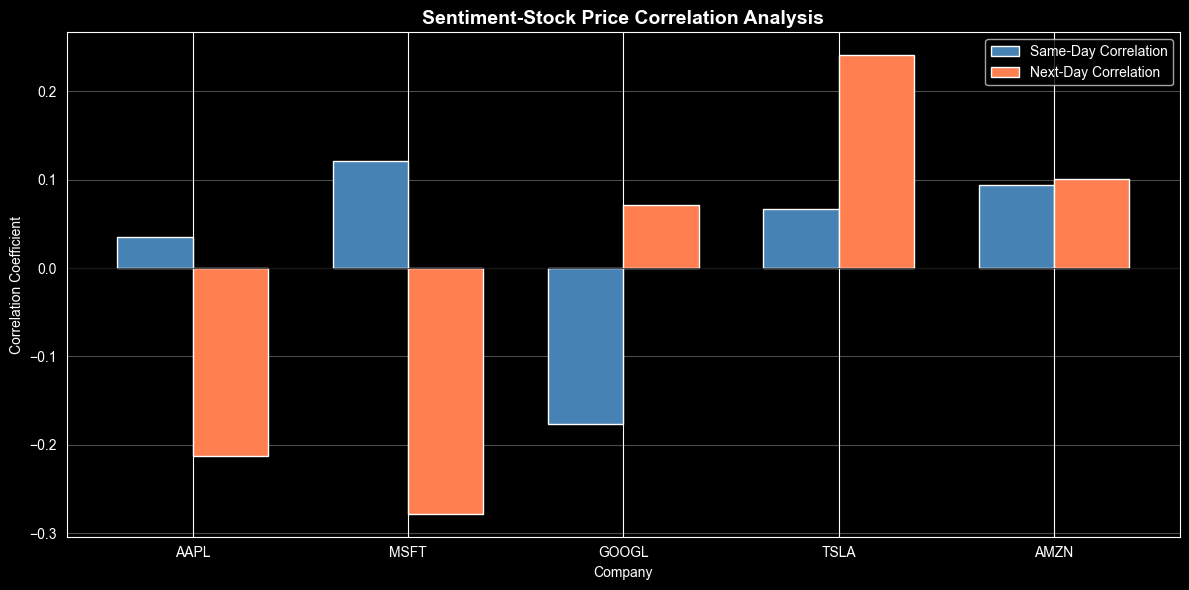

✅ All visualizations created!


In [43]:
if __name__ == "__main__":
    stock_data, sentiment_results, correlation_results = run_enhanced_pipeline()
    create_visualizations(stock_data, sentiment_results, correlation_results)